In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from spmd_reflection.cli import run
from spmd_reflection.postprocess.masks import (tci_il_mask, tci_rl_mask,
                                               mpi_il_mask, mpi_rl_mask,
                                               check_tci_il, check_tci_rl,
                                               check_mpi_il, check_mpi_rl)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.5,
    "font.size": 11})

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
CONFIG_PATH = PROJECT_ROOT / "config.yaml"

In [2]:
results = run(CONFIG_PATH)

freqs_hz  = results.frequency_hz
freqs_mhz = freqs_hz / 1e6

n_rx = results.il_phy_db.shape[1]
n_drops = results.il_tci_db.shape[1]

print(f"Frequenzbereich: {freqs_mhz[0]:.2f} – {freqs_mhz[-1]:.2f} MHz")
print(f"Anzahl Drops gesamt: {n_drops}")
print(f"Anzahl RX-Drops: {n_rx}")

Frequenzbereich: 0.30 – 40.00 MHz
Anzahl Drops gesamt: 3
Anzahl RX-Drops: 2


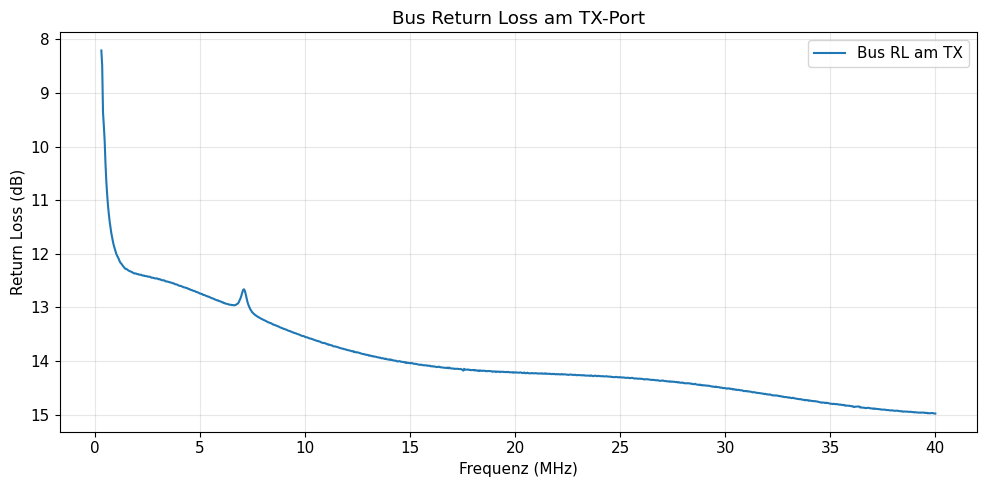

In [3]:
fig, ax = plt.subplots()

ax.plot(freqs_mhz, results.rl_db, label="Bus RL am TX")
ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("Return Loss (dB)")
ax.set_title("Bus Return Loss am TX-Port")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

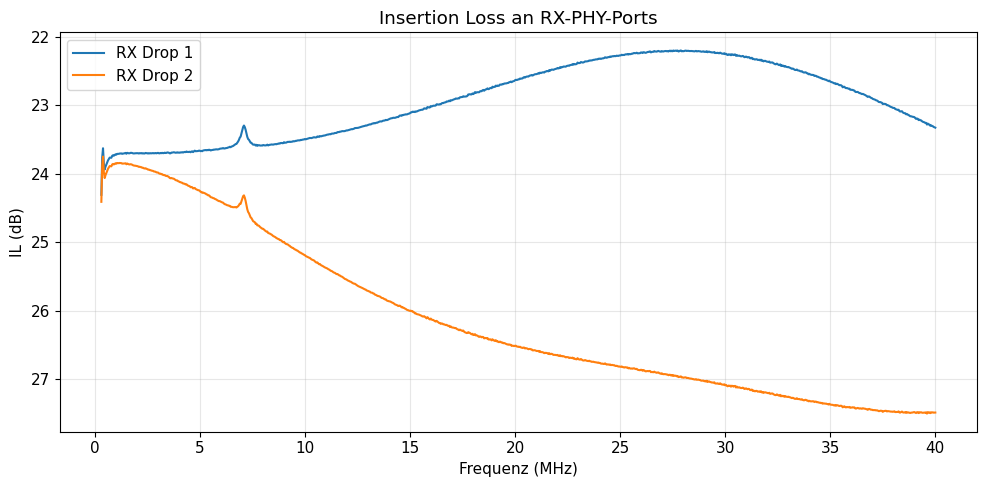

In [4]:
fig, ax = plt.subplots()

for i in range(n_rx):
    ax.plot(freqs_mhz, results.il_phy_db[:, i], label=f"RX Drop {i+1}")

ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("IL (dB)")
ax.set_title("Insertion Loss an RX-PHY-Ports")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

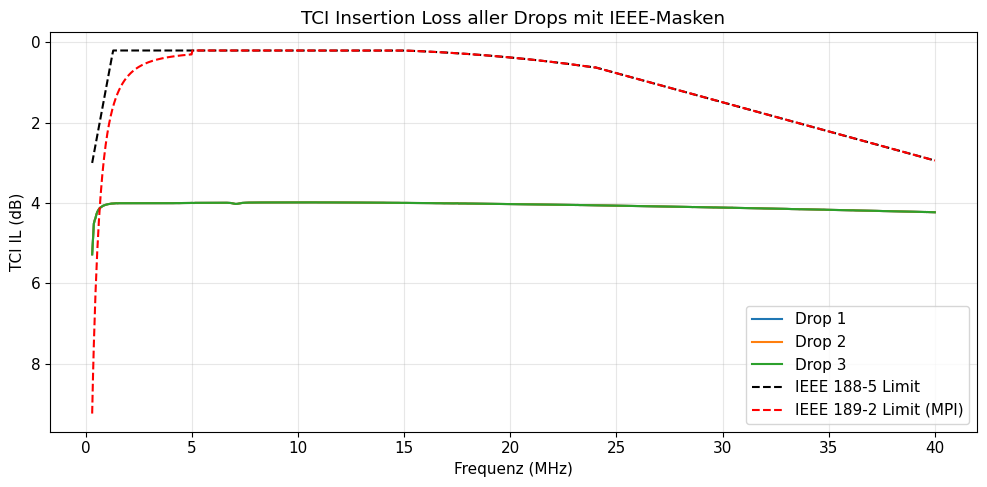

Drop 1: IL 188-5 ✗  IL 189-2 ✗
Drop 2: IL 188-5 ✗  IL 189-2 ✗
Drop 3: IL 188-5 ✗  IL 189-2 ✗


In [5]:
il_limit_188 = tci_il_mask(freqs_hz)
il_limit_189 = mpi_il_mask(freqs_hz)

fig, ax = plt.subplots()

for i in range(n_drops):
    ax.plot(freqs_mhz, results.il_tci_db[:, i], label=f"Drop {i+1}")

ax.plot(freqs_mhz, il_limit_188, "k--", label="IEEE 188-5 Limit")
ax.plot(freqs_mhz, il_limit_189, "r--", label="IEEE 189-2 Limit (MPI)")

ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("TCI IL (dB)")
ax.set_title("TCI Insertion Loss aller Drops mit IEEE-Masken")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

# Konformitäts-Check
ok_188 = check_tci_il(freqs_hz, results.il_tci_db)
ok_189 = check_mpi_il(freqs_hz, results.il_tci_db)
for i in range(n_drops):
    print(f"Drop {i+1}: IL 188-5 {'✓' if ok_188[:, i].all() else '✗'}  "
          f"IL 189-2 {'✓' if ok_189[:, i].all() else '✗'}")

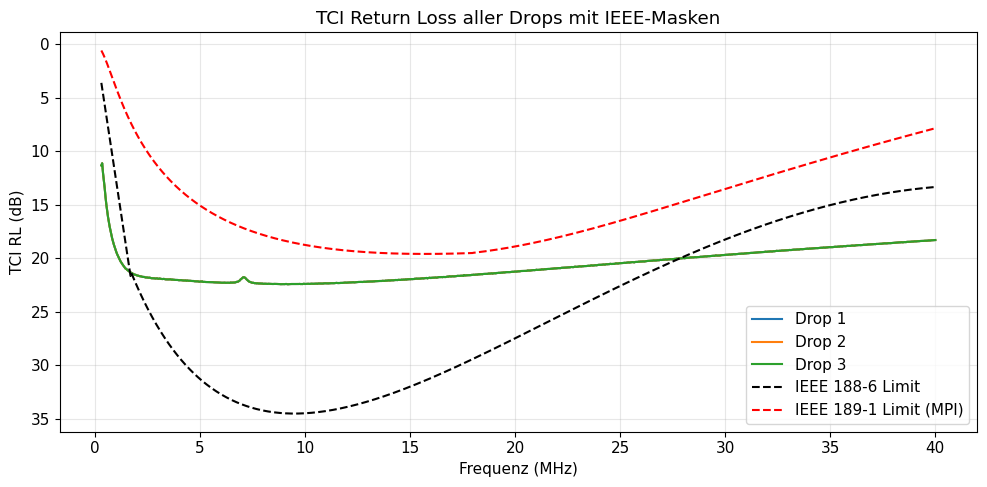

Drop 1: RL 188-6 ✗  RL 189-1 ✓
Drop 2: RL 188-6 ✗  RL 189-1 ✓
Drop 3: RL 188-6 ✗  RL 189-1 ✓


In [6]:
rl_limit_188 = tci_rl_mask(freqs_hz)
rl_limit_189 = mpi_rl_mask(freqs_hz)

fig, ax = plt.subplots()

for i in range(n_drops):
    ax.plot(freqs_mhz, results.rl_tci_db[:, i], label=f"Drop {i+1}")

ax.plot(freqs_mhz, rl_limit_188, "k--", label="IEEE 188-6 Limit")
ax.plot(freqs_mhz, rl_limit_189, "r--", label="IEEE 189-1 Limit (MPI)")

ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("TCI RL (dB)")
ax.set_title("TCI Return Loss aller Drops mit IEEE-Masken")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Konformitäts-Check
ok_188 = check_tci_rl(freqs_hz, results.rl_tci_db)
ok_189 = check_mpi_rl(freqs_hz, results.rl_tci_db)
for i in range(n_drops):
    print(f"Drop {i+1}: RL 188-6 {'✓' if ok_188[:, i].all() else '✗'}  "
          f"RL 189-1 {'✓' if ok_189[:, i].all() else '✗'}")

In [7]:
print("=" * 50)
print("KONFORMITÄTS-ZUSAMMENFASSUNG")
print("=" * 50)

checks = {
    "TCI IL (188-5)":  check_tci_il(freqs_hz, results.il_tci_db),
    "TCI RL (188-6)":  check_tci_rl(freqs_hz, results.rl_tci_db),
    "MPI IL (189-2)":  check_mpi_il(freqs_hz, results.il_tci_db),
    "MPI RL (189-1)":  check_mpi_rl(freqs_hz, results.rl_tci_db),
}

for check_name, conformant in checks.items():
    for i in range(n_drops):
        status = "PASS ✓" if conformant[:, i].all() else "FAIL ✗"
        print(f"  Drop {i+1} – {check_name}: {status}")
    print()

KONFORMITÄTS-ZUSAMMENFASSUNG
  Drop 1 – TCI IL (188-5): FAIL ✗
  Drop 2 – TCI IL (188-5): FAIL ✗
  Drop 3 – TCI IL (188-5): FAIL ✗

  Drop 1 – TCI RL (188-6): FAIL ✗
  Drop 2 – TCI RL (188-6): FAIL ✗
  Drop 3 – TCI RL (188-6): FAIL ✗

  Drop 1 – MPI IL (189-2): FAIL ✗
  Drop 2 – MPI IL (189-2): FAIL ✗
  Drop 3 – MPI IL (189-2): FAIL ✗

  Drop 1 – MPI RL (189-1): PASS ✓
  Drop 2 – MPI RL (189-1): PASS ✓
  Drop 3 – MPI RL (189-1): PASS ✓

